In [ ]:
import marimo as mo

In [ ]:
mo._runtime.context.get_context().marimo_config["runtime"]["output_max_bytes"] = 10000000000

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Objective function

The penalty function used as the objective to find the best design parameter boundaries is set using the following:

1. Calculate the trial properties for the candidate design, includes.
   - $\alpha_{\texttt{found}}$
   - $\beta_{\texttt{found}}$
3. Penalty parameter is instantiated, $p$, set to the single stage sample size.
4. Number of restarts, $r$
5. Worst case expected sample size, $ESS_w$

$$f = \mathbb{I}\{\alpha_{\texttt{found}} > \alpha\} \left(p + p\left(\frac{\alpha_{\texttt{found}}-\alpha}{\alpha}\right)\right) + \mathbb{I}\{\beta_{\texttt{found}} > \beta\}\left(p + p\left(\frac{\beta_{\texttt{found}}-\beta}{\beta}\right)\right) +$$

$$\mathbb{I}\{(\alpha_{\texttt{found}} > \alpha\,\,\texttt{or}\,\,\beta_{\texttt{found}} > \beta) \,\,\texttt{and}\,\,(r\ge-1)\}\left(\frac{p}{10}\right) + ESS_w$$

In [ ]:
def objective_function(
        alpha,
        alpha_found,
        beta,
        beta_found,
        p,
        r,
        ess_worst
):
    function_value = 0

    if alpha_found > alpha:
        function_value += p * (p * ((alpha_found-alpha)/alpha) )
    if beta_found > beta:
        function_value += p * (p * ((beta_found-beta)/beta) )
    if (alpha_found > alpha or beta_found > beta) and r >= -1:
        function_value += p/10

    function_value += ess_worst

    return function_value

In [ ]:
alpha_found = np.linspace(0, 1, 200)
beta_found = np.copy(alpha_found)

p = 154
r = -2

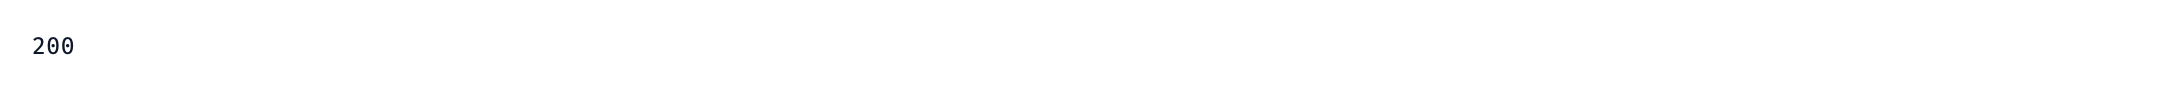

In [ ]:
len(alpha_found)

In [ ]:
objective_function_z = np.empty(shape=(len(alpha_found), len(beta_found)))

In [ ]:
objective_function_z.shape

In [ ]:
# create values when r is -2
for _i, alpha_val in enumerate(alpha_found):
    for _j, beta_val in enumerate(beta_found):
        objective_function_z[_i, _j] = objective_function(
            alpha = 0.05,
            alpha_found = alpha_val,
            beta = 0.1,
            beta_found = beta_val, 
            p = p, 
            r = r, 
            ess_worst= 120
        )

In [ ]:
objective_function_z_r1 = np.ones(shape=(len(alpha_found), len(beta_found))) * 10000

In [ ]:
# create values when r is 1
for _i, _alpha_val in enumerate(alpha_found):
    for _j, _beta_val in enumerate(beta_found):
        objective_function_z_r1[_i, _j] = objective_function(
            alpha = 0.05,
            alpha_found = _alpha_val,
            beta = 0.1,
            beta_found = _beta_val, 
            p = p, 
            r = 1, 
            ess_worst= 120
        )

In [ ]:
X, Y = np.meshgrid(alpha_found, beta_found)

In [ ]:
fig_3d = go.Figure()

fig_3d.add_trace(go.Surface(z=objective_function_z, x=X, y=Y, name="Surface 1"))
fig_3d.add_trace(go.Surface(z=objective_function_z_r1, x=X, y=Y, name="Surface 2"))

fig_3d.update_scenes(
    xaxis_title_text="alpha",
    yaxis_title_text="beta",
    zaxis_title_text="penalty"
)
fig_3d.show()

<marimo-plotly data-figure='{"data":[{"name":"Surface 1","x":{"dtype":"f8","bdata":"...","shape":"200, 200"},"y":{"dtype":"f8","bdata":"...","shape":"200, 200"},"z":{"dtype":"f8","bdata":"...","shape":"200, 200"},"type":"surface"},{"name":"Surface 2","x":{"dtype":"f8","bdata":"...","shape":"200, 200"},"y":{"dtype":"f8","bdata":"...","shape":"200, 200"},"z":{"dtype":"f8","bdata":"...","shape":"200, 200"},"type":"surface"}],"layout":{"template":{"data":{"histogram2dcontour":[{"type":"histogram2dcontour","colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]]}],"choropleth":[{"type":"choropleth","colorbar":{"outlinewidth":0,"ticks":""}}],"histogram2d":[{"type":"histogram2d","colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]]}],"heatmap":[{"type":"heatmap","colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]]}],"contourcarpet":[{"type":"contourcarpet","colorbar":{"outlinewidth":0,"ticks":""}}],"contour":[{"type":"contour","colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]]}],"surface":[{"type":"surface","colorbar":{"outlinewidth":0,"ticks":""},"colorscale":[[0.0,"#0d0887"],[0.1111111111111111,"#46039f"],[0.2222222222222222,"#7201a8"],[0.3333333333333333,"#9c179e"],[0.4444444444444444,"#bd3786"],[0.5555555555555556,"#d8576b"],[0.6666666666666666,"#ed7953"],[0.7777777777777778,"#fb9f3a"],[0.8888888888888888,"#fdca26"],[1.0,"#f0f921"]]}],"mesh3d":[{"type":"mesh3d","colorbar":{"outlinewidth":0,"ticks":""}}],"scatter":[{"fillpattern":{"fillmode":"overlay","size":10,"solidity":0.2},"type":"scatter"}],"parcoords":[{"type":"parcoords","line":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scatterpolargl":[{"type":"scatterpolargl","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"bar":[{"error_x":{"color":"#2a3f5f"},"error_y":{"color":"#2a3f5f"},"marker":{"line":{"color":"#E5ECF6","width":0.5},"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"bar"}],"scattergeo":[{"type":"scattergeo","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scatterpolar":[{"type":"scatterpolar","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"histogram":[{"marker":{"pattern":{"fillmode":"overlay","size":10,"solidity":0.2}},"type":"histogram"}],"scattergl":[{"type":"scattergl","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scatter3d":[{"type":"scatter3d","line":{"colorbar":{"outlinewidth":0,"ticks":""}},"marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scattermap":[{"type":"scattermap","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scattermapbox":[{"type":"scattermapbox","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scatterternary":[{"type":"scatterternary","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"scattercarpet":[{"type":"scattercarpet","marker":{"colorbar":{"outlinewidth":0,"ticks":""}}}],"carpet":[{"aaxis":{"endlinecolor":"#2a3f5f","gridcolor":"white","linecolor":"white","minorgrid

# Simulated annealing

## Loop 1

In the simulated annealing function, the steps are:

Before the first loop within the simulated annealing code, the initial design is set as the triangular design, call it $D$, and $f_{\texttt{min}}$ is set as the current minimum objective function value calculated by $f$ above.

Perform this <span style="color:red"><b>loop</span></b> $n_{\texttt{generate}}$ times:
1. Generate a candidate design, $D'$
2. Calculate the objective function value for this design, $f'$.
3. Reduce the size of the search space $B$ by $\rho_{\texttt{sigma}}$
4. Increment the counter for the number of generated designs (limit is 10,000)
5. Perform simulated annealing:
    - Generate a $U(0, 1)$ random variable, $x$
    - <span style="color:red"><b>IF</span></b> $\exp\left\{-\frac{(f' - f)}{T}\right\}\ge x$:
        - Set $f'$ to $f$
        - Reduce $T$ by $\rho_{\texttt{cost}}$, calculated as $T\cdot\rho_{\texttt{cost}}$
        - Set the generated candidate design $D'$ to the current design $D$
        - <span style="color:red"><b>IF</span></b> $f' < f_{\texttt{min}}$:
            - Save the current design $D$ as the "best" design $D_{\texttt{min}}$
            - Set $f_{\texttt{min}}$ to $f'$
            - Reset a counter of number of loops since objective function reduction to 0
        - <span style="color:red"><b>ELSE</span></b> increment number since objective function reduction
    - <span style="color:red"><b>ELSE</span></b> increment number since objective function reduction
6. Every 25th run, reset $D$ to $D_{\texttt{min}}$ and reset $f$ to $f_{\texttt{min}}$

After $n_{\texttt{generate}}$ times:
1. Set $D$ to $D_{\texttt{min}}$
2. Set $f$ to $f_{\texttt{min}}$
3. Reset $T$ to its starting value
4. Reset box shrinker to starting value
5. Reset $n_{\texttt{generate}}$ to 0
6. Increment number of restarts

Once these are reset, the loop restarts with the design $D$ set at the current minimum $D_{\texttt{min}}$. The simulated annealing temperature $T$ and the search space $B$ are reset and the search begins again. This entire loop is completed at least $n_{\texttt{restarts}}$ times.

## Loop 2

After the above loop is finished,

1. The sample size changed to an integer using `floor()`.
2. The minimum objective function value, $f_{\texttt{min}}$, is recalculated with this new integer sample size.
3. $n_{\texttt{generate}}$ is reset to 0.
4. $n_{\texttt{restarts}}$ is reduced by 4.

The loop restarts with the sample size fixed exactly as above except that in step 6:
6. Every 10th run, reset $D$ to $D_{\texttt{min}}$ and reset $f$ to $f_{\texttt{min}}$

# The path to the minimum

In [ ]:
designs = pd.read_csv(filepath_or_buffer="/tf/2026-03-t14/designs.txt", sep=" ",
                      index_col=False,
                      names=["sample_size", "lower1", "upper1", "lower2", "upper2", "lower3", "upper3"])

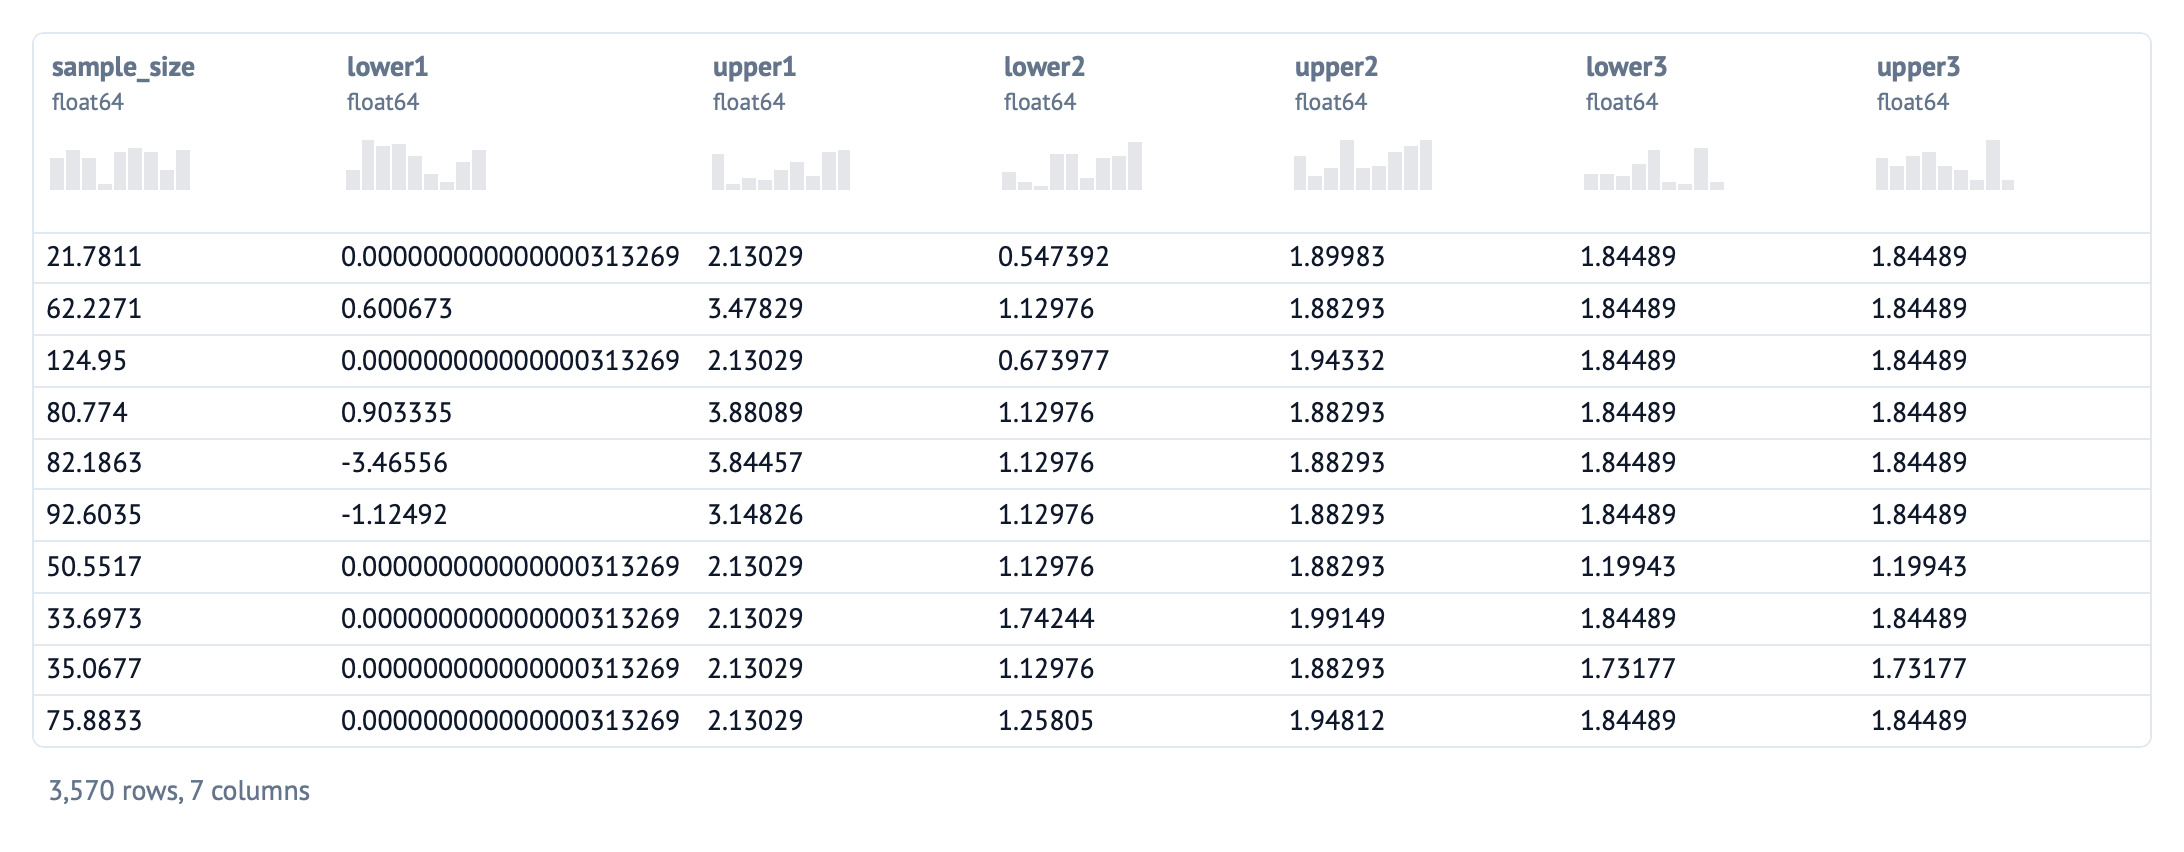

In [ ]:
designs

In [ ]:
objective_function_vals = pd.read_csv(filepath_or_buffer="/tf/2026-03-t14/objective_function_vals.txt", sep=" ",
                                      index_col=False, names = ["obj_func_val"])

In [ ]:
temperature = pd.read_csv(filepath_or_buffer="/tf/2026-03-t14/temperature.txt", sep=" ",
                                      index_col=False, names = ["temp"])

In [ ]:
slider = mo.ui.slider(start=0, stop=3500, label="Slider", value=3)

In [ ]:
slider

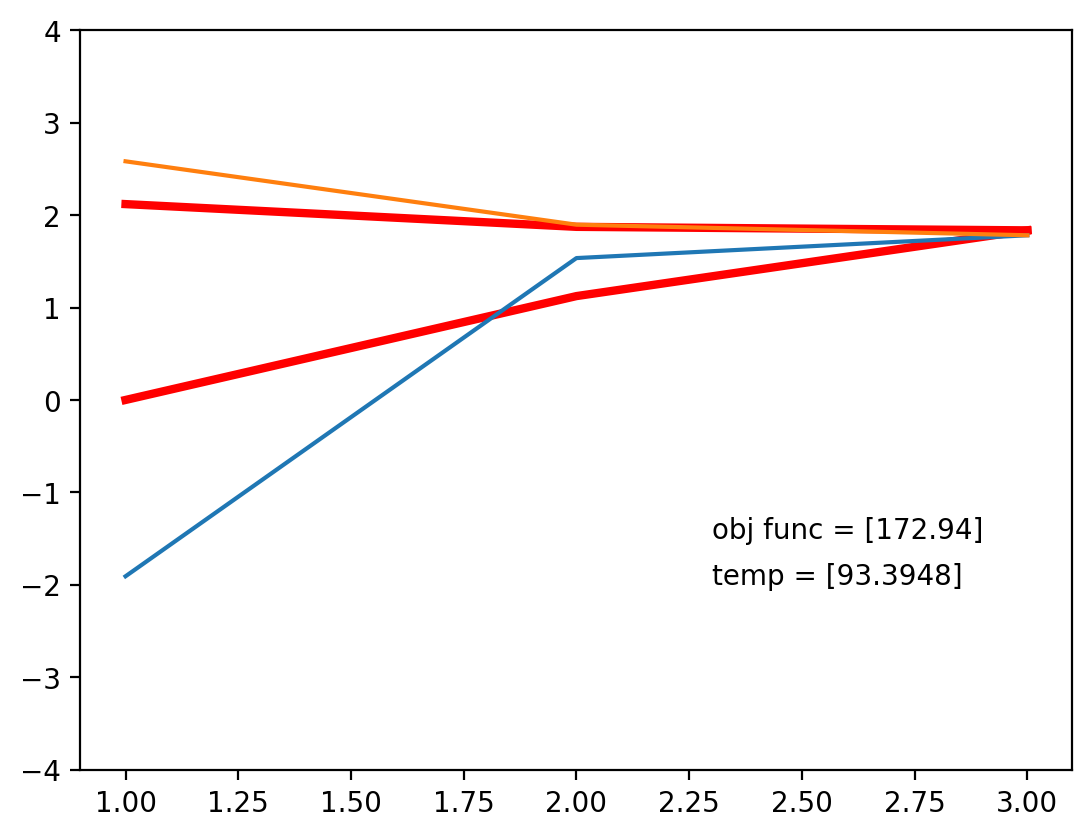

In [ ]:
_fig, _ax = plt.subplots()

_ax.plot([1,2,3], [2.11957748, 1.87345951, 1.83560794], lw=3, color="red")
_ax.plot([1,2,3], [6.28553399e-16, 1.12407571e+00, 1.83560794e+00], lw=3, color="red")

_ax.plot([1,2,3], designs.iloc[slider.value, [1, 3, 5]])
_ax.plot([1,2,3], designs.iloc[slider.value, [2, 4, 6]])
_ax.text(2.3, -2, str("temp = ")+str(np.array(temperature.iloc[slider.value])))
_ax.text(2.3, -1.5, str("obj func = ")+str(np.array(objective_function_vals.iloc[slider.value])))
_ax.set_ylim([-4, 4])

_fig

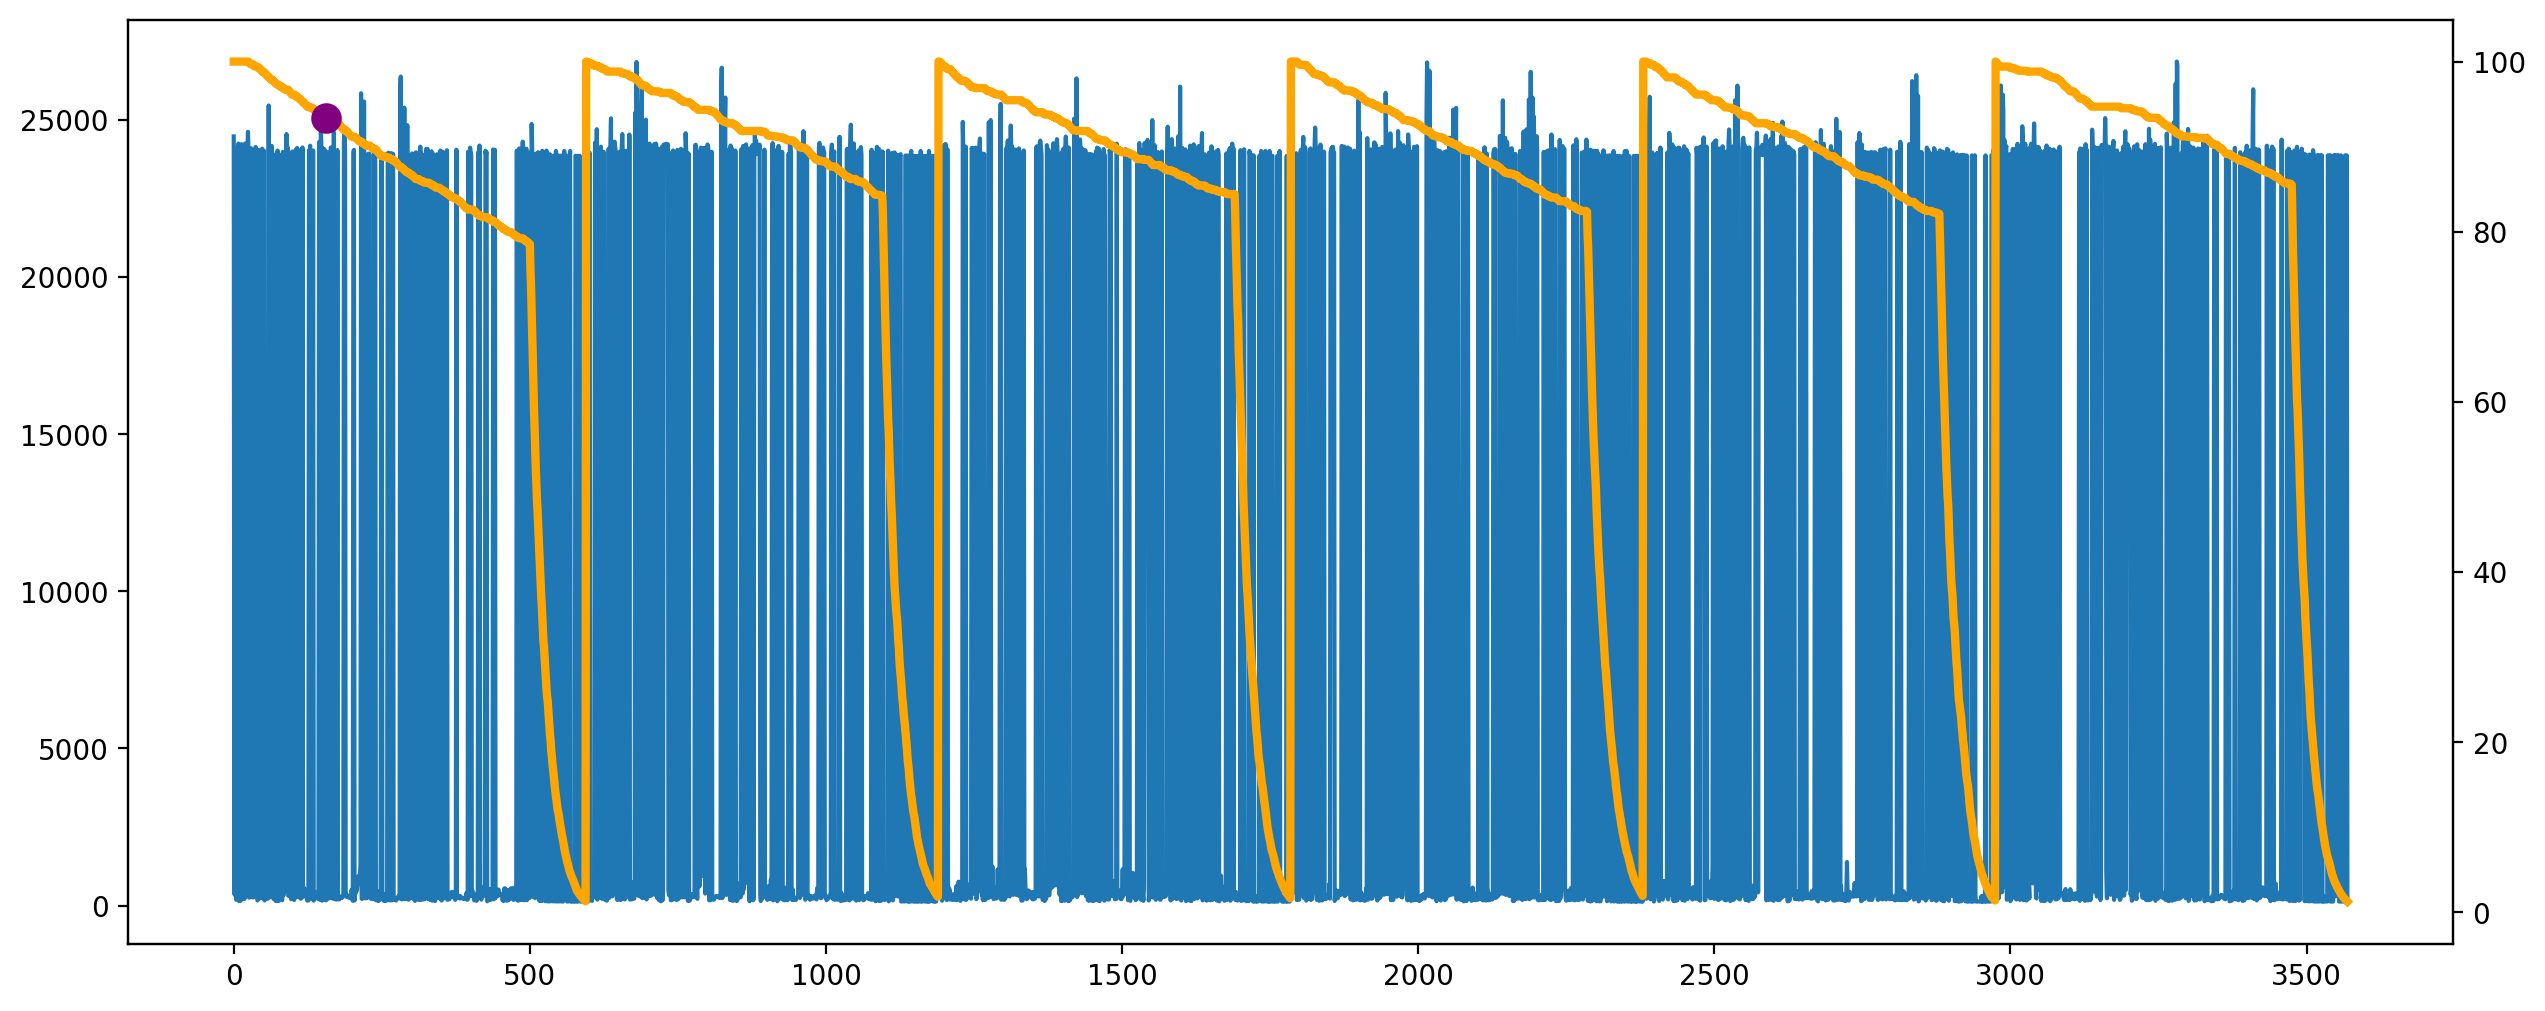

In [ ]:
_fig, _ax = plt.subplots(figsize=(15,6))

_ax.plot(objective_function_vals)
_ax2 = _ax.twinx()
_ax2.plot(temperature, color = "orange", lw=3)
_ax2.scatter(x = slider.value, y = temperature.iloc[slider.value], marker="o", color = "purple", s=100,
             zorder = 3)

_fig

# Five stage design exploration

In [ ]:
five_stage = pd.read_csv(filepath_or_buffer="/tf/cpp_workspace/wason_delta_minimax/minimax_tests/5_stage_designs.txt",
                         sep=" ", index_col=False)

In [ ]:
slider2 = mo.ui.slider(start=0, stop=99, label="Slider", value=3)

In [ ]:
slider2

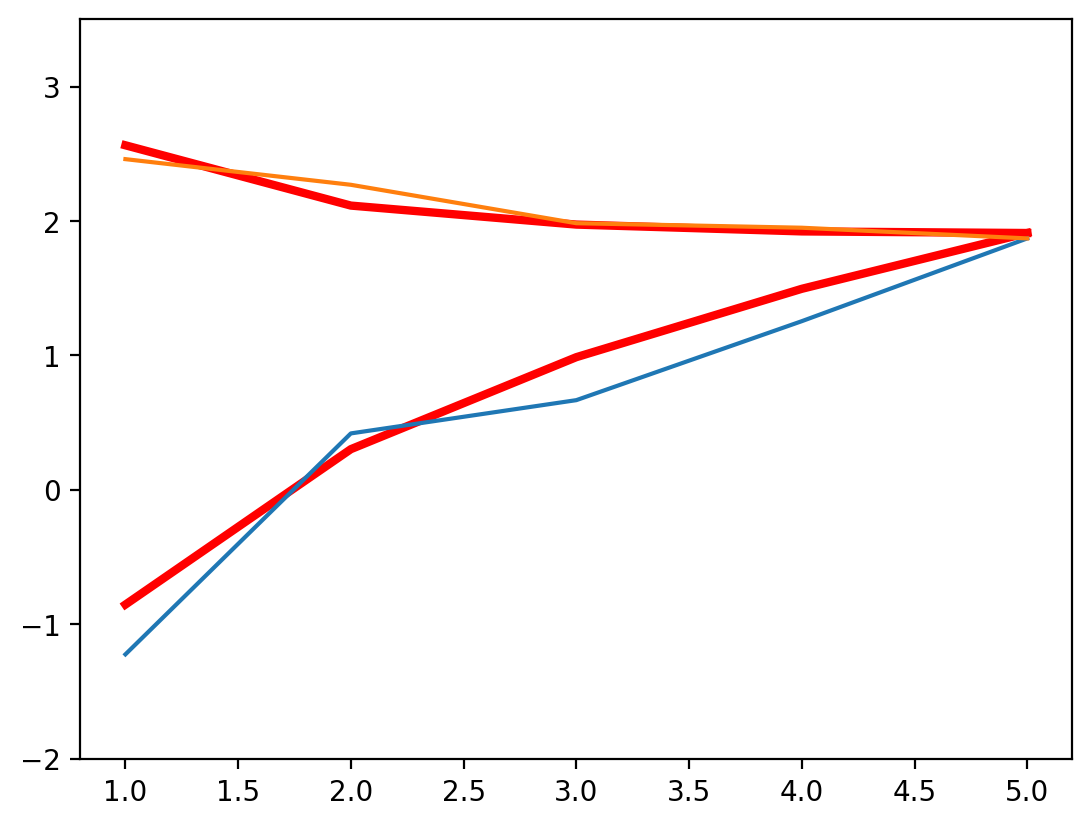

In [ ]:
# 5-stage triangular boundary 
# 42 -0.854333 2.563 0.302052 2.11437 0.986499 1.973 1.49508 1.92225 1.91035 1.91035 

_fig, _ax = plt.subplots()

_ax.plot([1,2,3,4,5], [2.563, 2.11437, 1.973, 1.92225, 1.91035], lw=3, color="red")
_ax.plot([1,2,3,4,5], [-0.854333, 0.302052, 0.986499, 1.49508, 1.91035], lw=3, color="red")

_ax.plot([1,2,3,4,5], five_stage.iloc[slider2.value, [17, 19, 21, 23, 25]])
_ax.plot([1,2,3,4,5], five_stage.iloc[slider2.value, [18, 20, 22, 24, 26]])

_ax.set_ylim([-2, 3.5])

_fig

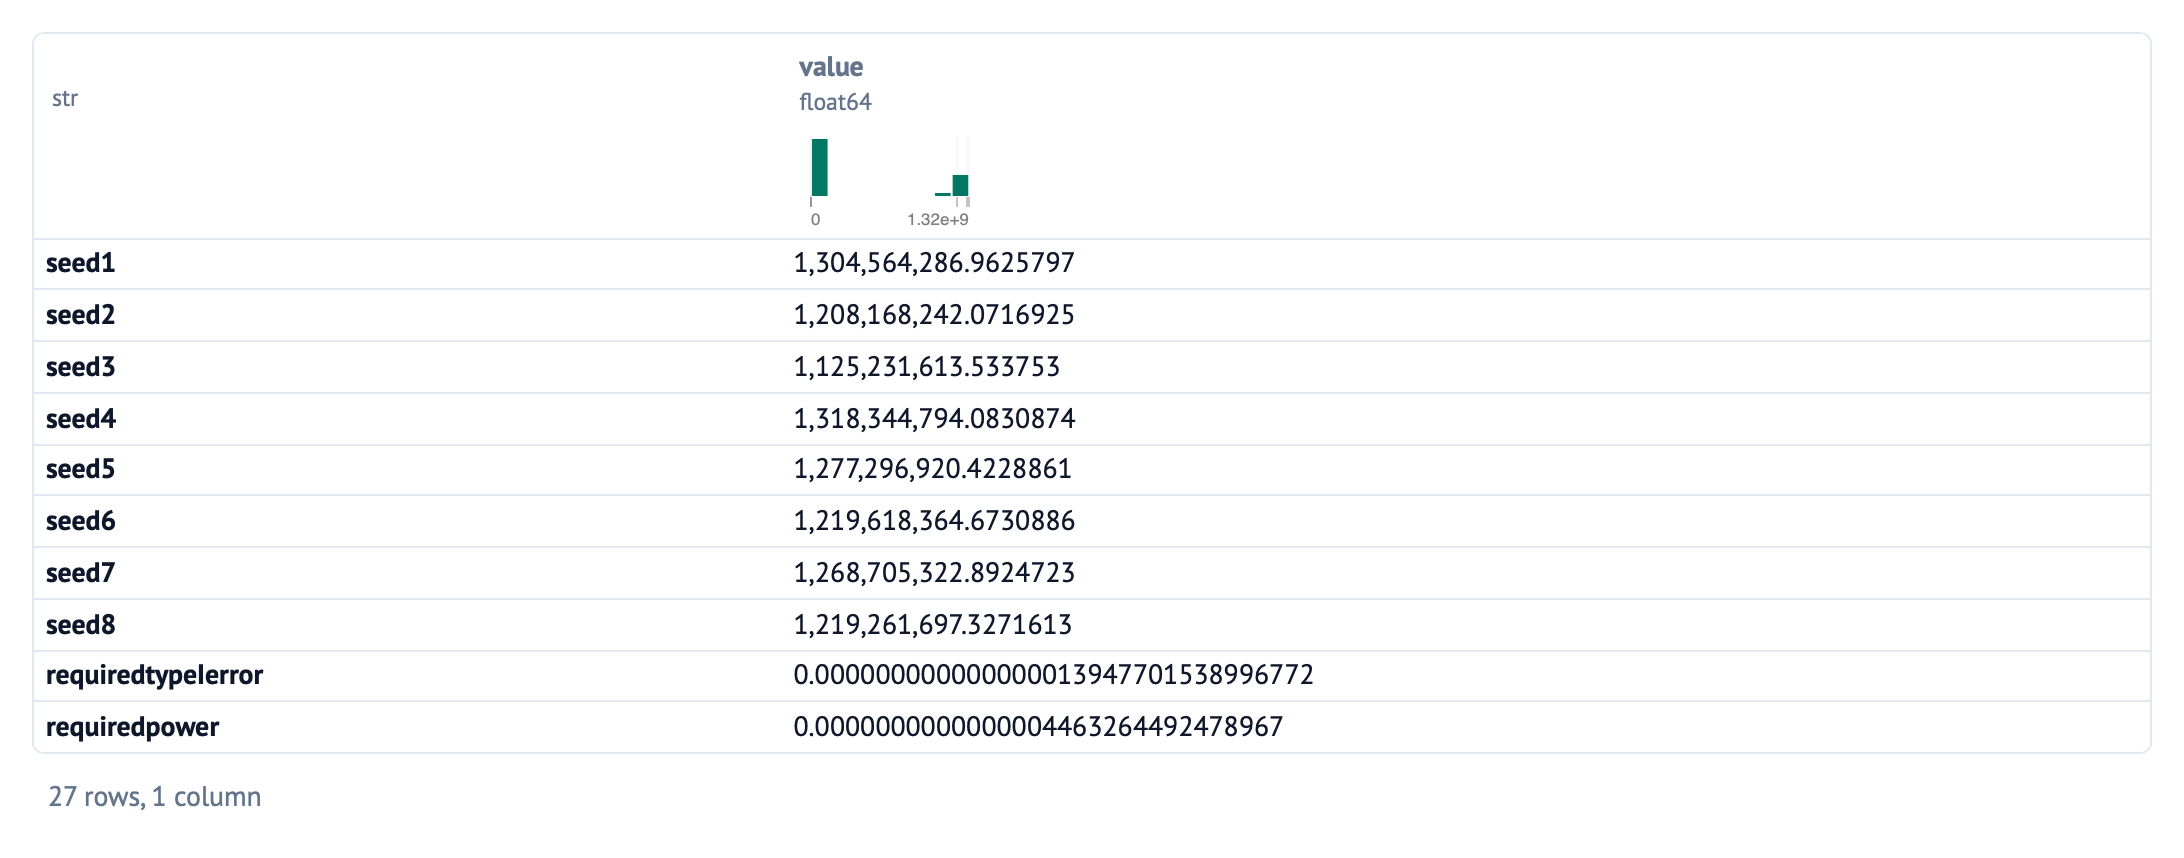

In [ ]:
five_stage.std()

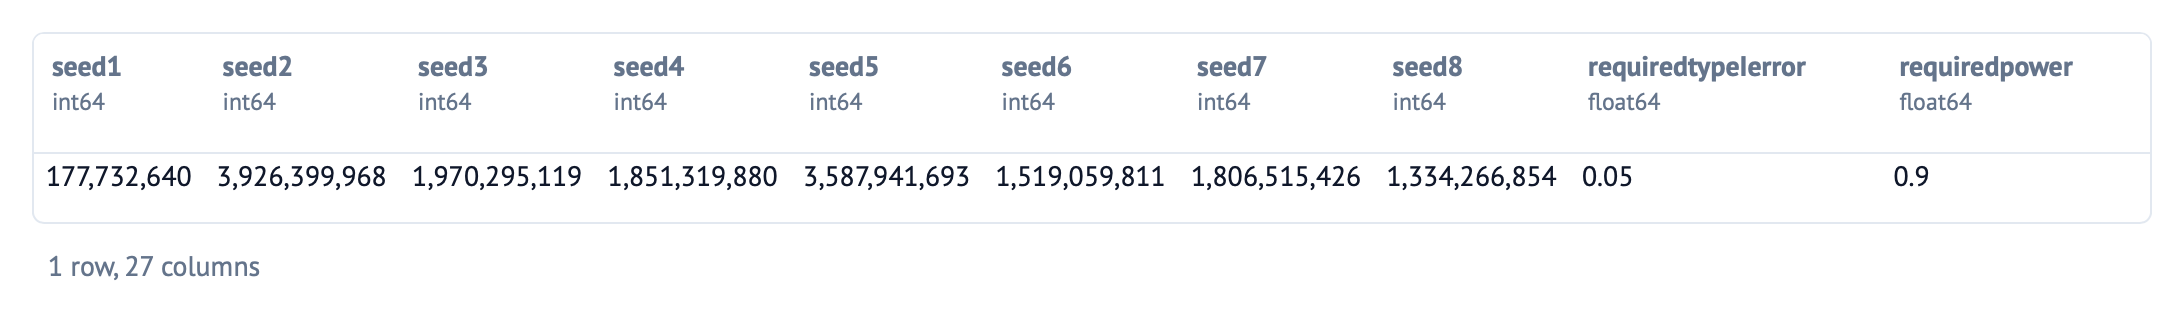

In [ ]:
five_stage[five_stage["expected_sample_size_dm"]==116.951]